# Notebook 10 — Backtest Engine

**Goal**: Run a full backtest with realistic Groww transaction costs.

---

## What the Backtest Simulates

Starting with ₹1,00,000 capital, we simulate daily trading:

1. **Signal generation**: Use ensemble model predictions
2. **Position sizing**: Half-Kelly with 10% max per position
3. **Entry/Exit**: Based on predicted direction and confidence
4. **Stop-loss**: 3% per position (risk management)
5. **Take-profit**: 10% per position (lock in gains)
6. **Transaction costs**: Full Groww fee structure on every trade
7. **Slippage**: 0.1% assumed slippage on execution

## Groww Cost Structure (per trade)

| Component | Equity Delivery |
|-----------|----------------|
| Brokerage | ₹20 or 0.05% |
| STT | 0.1% (buy+sell) |
| Exchange Txn | 0.00345% |
| GST | 18% on brokerage |
| SEBI Fee | ₹10 per crore |
| Stamp Duty | 0.015% (buy) |
| DP Charges | ₹15.93 (sell) |

These costs add up! A round-trip on ₹50K costs ~₹150-200, which is 0.3-0.4%.
This means the model needs to predict moves > 0.4% just to break even.

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtest import BacktestEngine, GrowwCostCalculator
from src.backtest.metrics import compute_all_metrics
from src.utils.constants import *
from src.utils.helpers import plot_equity_curve, plot_drawdown, plot_monthly_returns_heatmap

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Predictions & Price Data

In [2]:
# --- Load predictions ---
# Prefer model predictions with date column (needed for signal construction)
predictions = None
for model_name in ["xgboost", "lightgbm"]:
    path = DATA_DIR / "processed" / f"{model_name}_predictions.parquet"
    if path.exists():
        predictions = pd.read_parquet(path)
        print(f"✅ Loaded {model_name} predictions: {len(predictions)} samples")
        break

if predictions is None:
    # Fallback to ensemble (no date column — limited backtest capability)
    pred_path = DATA_DIR / "processed" / "ensemble_predictions.parquet"
    if pred_path.exists():
        predictions = pd.read_parquet(pred_path)
        print(f"✅ Loaded ensemble predictions: {len(predictions)} samples (no date column)")
    else:
        print("⚠️ No predictions found — run model notebooks first")

# --- Load price data (exclude prediction files) ---
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.parquet"))
price_files = [f for f in processed_files if "prediction" not in f.stem]

price_data = {}
for f in price_files:
    ticker = f.stem  # e.g., "RELIANCE.NS" — use stem directly
    df = pd.read_parquet(f)
    if "Close" in df.columns:
        price_data[ticker] = df

sample_tickers = sorted(price_data.keys())[:30]  # Same 30 as training notebooks
print(f"✅ Loaded price data for {len(price_data)} tickers ({len(sample_tickers)} used)")

if predictions is not None:
    print(f"\nPrediction columns: {list(predictions.columns)}")
    if "date" in predictions.columns:
        print(f"Date range: {predictions['date'].min().date()} → {predictions['date'].max().date()}")

✅ Loaded xgboost predictions: 188457 samples
✅ Loaded price data for 122 tickers (30 used)

Prediction columns: ['date', 'Ticker', 'actual', 'predicted', 'fold']
Date range: 2019-03-26 → 2025-11-11


## Step 2 — Run Backtest Engine

The `BacktestEngine` simulates trading with:
- Entry when predicted return > threshold
- Exit at stop-loss (-3%) or take-profit (+10%)
- Full Groww transaction costs on every trade

In [3]:
results = None

if predictions is not None:
    # Build PER-STOCK signals from predictions (not portfolio-level mean)
    signals_df = pd.DataFrame()

    if "date" in predictions.columns and "Ticker" in predictions.columns:
        # Per-ticker signals — use each ticker's own prediction
        # Signal threshold lowered to 0.5% to generate more trades for statistical significance
        signal_threshold = 0.005  # 0.5% predicted return threshold

        signals_list = []
        for _, row in predictions.iterrows():
            ticker = row["Ticker"]
            pred_ret = row["predicted"]
            signal = 1 if pred_ret > signal_threshold else (
                -1 if pred_ret < -signal_threshold else 0
            )
            confidence = min(abs(pred_ret) * 100, 1.0)

            if ticker in price_data and row["date"] in price_data[ticker].index:
                signals_list.append({
                    "Date": row["date"],
                    "Ticker": ticker,
                    "Signal": signal,
                    "Confidence": confidence,
                    "Predicted_Range": abs(pred_ret),
                    "Predicted_Return": pred_ret,
                })

        signals_df = pd.DataFrame(signals_list)
        print(f"Built {len(signals_df)} per-stock signals across {signals_df['Ticker'].nunique()} tickers")
        print(f"Signal distribution: {signals_df['Signal'].value_counts().to_dict()}")
        print(f"Signal threshold: {signal_threshold:.1%}")
    elif "date" in predictions.columns:
        # Fallback: portfolio-level signals (no Ticker column)
        daily_pred = predictions.groupby("date").agg(
            mean_predicted=("predicted", "mean"),
        ).reset_index()
        signal_threshold = 0.005

        signals_list = []
        for _, row in daily_pred.iterrows():
            pred_ret = row["mean_predicted"]
            signal = 1 if pred_ret > signal_threshold else (
                -1 if pred_ret < -signal_threshold else 0
            )
            confidence = min(abs(pred_ret) * 100, 1.0)

            for ticker in sample_tickers:
                if ticker in price_data and row["date"] in price_data[ticker].index:
                    signals_list.append({
                        "Date": row["date"],
                        "Ticker": ticker,
                        "Signal": signal,
                        "Confidence": confidence,
                        "Predicted_Range": abs(pred_ret),
                        "Predicted_Return": pred_ret,
                    })
        signals_df = pd.DataFrame(signals_list)
        print(f"Built {len(signals_df)} portfolio-level signals across {len(sample_tickers)} tickers")
        print(f"Signal distribution: {signals_df['Signal'].value_counts().to_dict()}")
    else:
        print("⚠️ Predictions lack date column — cannot build per-date signals")

    if len(signals_df) > 0:
        # BacktestEngine with improved configuration:
        #   - 0.5% signal threshold (more trades for statistical significance)
        #   - ATR-based dynamic stop-loss (1.5x ATR per stock)
        #   - Daily rebalancing (act on signals promptly)
        #   - 3-day minimum hold (prevents churning)
        engine = BacktestEngine(
            initial_capital=50_000,
            stop_loss_pct=0.03,
            take_profit_pct=0.10,
            max_positions=8,
            max_position_pct=0.12,
            min_signal_threshold=0.005,
            min_hold_days=3,
            require_model_agreement=False,   # No Model_Agreement col in backtest data
            require_volume_confirmation=False, # No Volume_Ratio col in backtest data
            use_atr_stop=True,
            atr_stop_multiplier=1.5,
            rebalance_frequency="daily",
        )

        results = engine.run(
            signals=signals_df,
            price_data=price_data,
        )

        print("\nBacktest Results:")
        print("=" * 50)
        print(f"Starting capital:    ₹{50_000:>12,.0f}")
        print(f"Final capital:       ₹{results['equity_curve'].iloc[-1]:>12,.0f}")
        print(f"Total return:        {(results['equity_curve'].iloc[-1] / 50_000 - 1):>10.2%}")
        print(f"Total trades:        {len(results['trade_log']):>10d}")
        print(f"Total costs:         ₹{results['cost_analysis']['Total Costs (₹)']:>12,.0f}")

Built 185349 per-stock signals across 90 tickers
Signal distribution: {0: 130417, 1: 48828, -1: 6104}
Signal threshold: 0.5%

Backtest Results:
Starting capital:    ₹      50,000
Final capital:       ₹      55,713
Total return:            11.43%
Total trades:               117
Total costs:         ₹       5,353


## Step 3 — Equity Curve & Drawdown

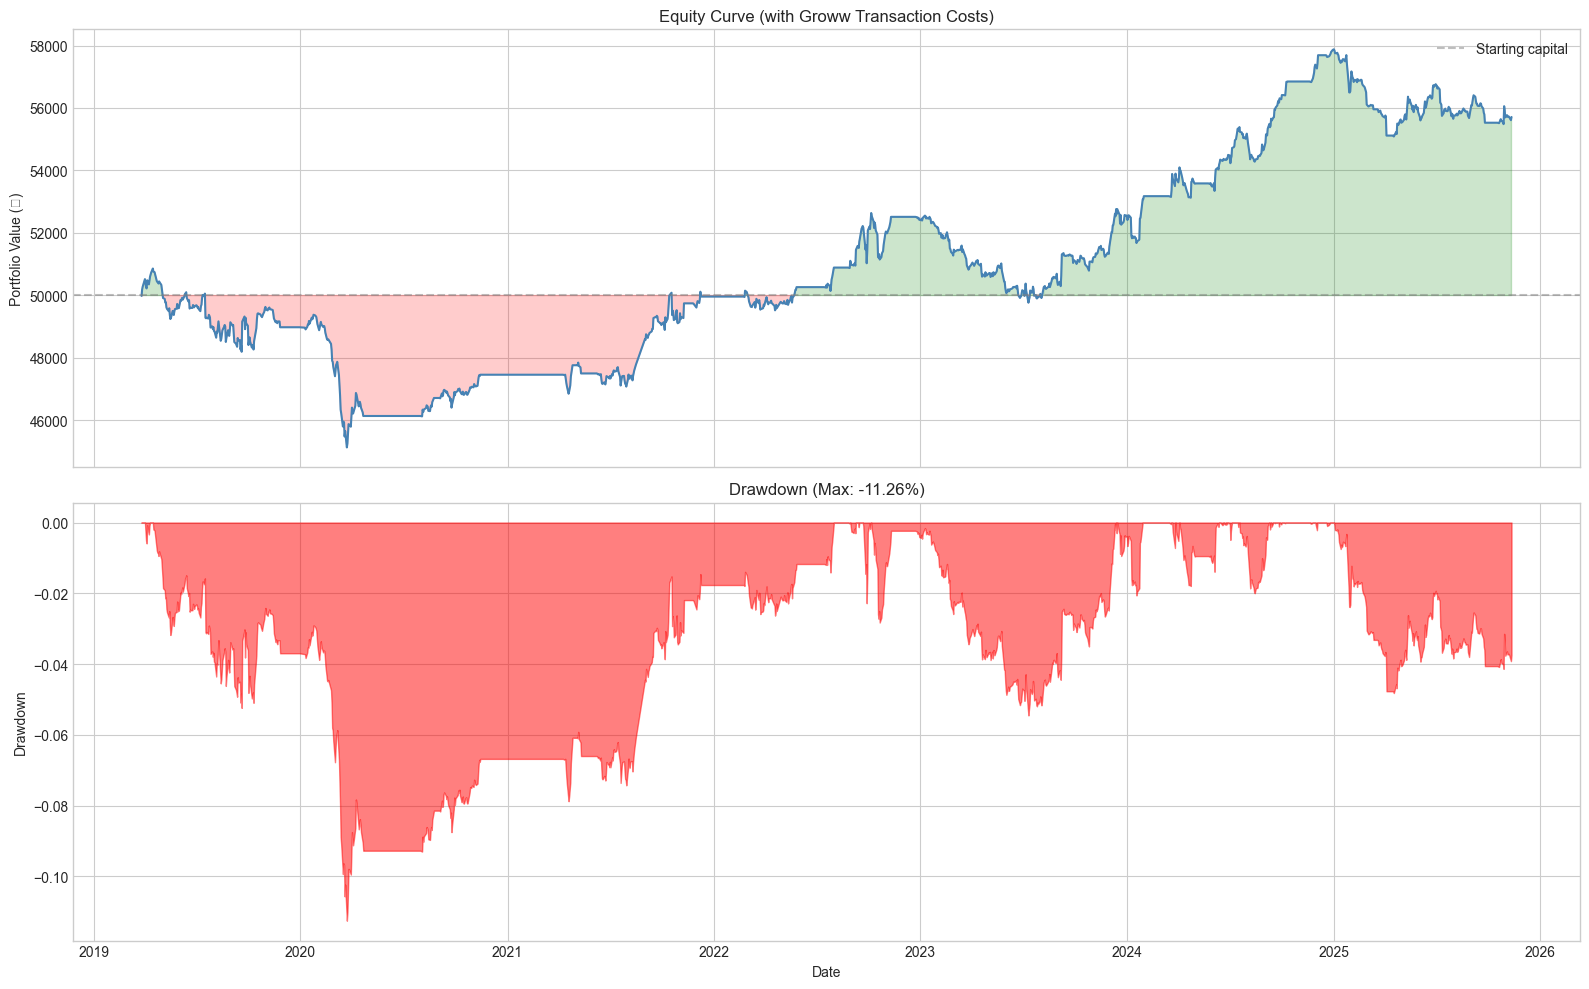

In [4]:
if results is not None and "equity_curve" in results:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    equity = results["equity_curve"]

    # Equity curve
    axes[0].plot(equity.index, equity.values, color="steelblue", lw=1.5)
    axes[0].axhline(50_000, color="gray", linestyle="--", alpha=0.5, label="Starting capital")
    axes[0].fill_between(equity.index, 50_000, equity.values,
                         where=equity.values >= 50_000, alpha=0.2, color="green")
    axes[0].fill_between(equity.index, 50_000, equity.values,
                         where=equity.values < 50_000, alpha=0.2, color="red")
    axes[0].set_ylabel("Portfolio Value (₹)")
    axes[0].set_title("Equity Curve (with Groww Transaction Costs)")
    axes[0].legend()

    # Drawdown
    peak = equity.cummax()
    drawdown = (equity - peak) / peak
    axes[1].fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.5)
    axes[1].set_ylabel("Drawdown")
    axes[1].set_title(f"Drawdown (Max: {drawdown.min():.2%})")
    axes[1].set_xlabel("Date")

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "backtest_equity_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 4 — Transaction Cost Analysis

How much do Groww fees eat into profits?

In [5]:
if results is not None and "cost_analysis" in results:
    cost = results["cost_analysis"]

    print("Transaction Cost Breakdown:")
    print("=" * 50)
    for key, value in cost.items():
        if isinstance(value, (int, float)):
            print(f"  {key:25s}: ₹{value:>10,.2f}")

    # Cost as % of total PnL
    total_pnl = results["equity_curve"].iloc[-1] - 50_000
    total_costs = cost.get("Total Costs (₹)", 0)
    cost_pct = total_costs / abs(total_pnl) * 100 if total_pnl != 0 else 0
    print(f"\n  Costs as % of PnL: {cost_pct:.1f}%")
    print(f"  This shows why realistic cost modelling is critical!")

Transaction Cost Breakdown:
  Total Costs (₹)          : ₹  5,353.05
  Avg Cost per Trade (₹)   : ₹     45.75
  Costs as % of Initial    : ₹     10.71
  Total Trades             : ₹    117.00
  Winning Trades           : ₹     51.00
  Losing Trades            : ₹     66.00

  Costs as % of PnL: 93.7%
  This shows why realistic cost modelling is critical!


## Step 5 — Trade Log Analysis

In [6]:
if results is not None and "trade_log" in results and results["trade_log"]:
    # Use engine's formatter for nicely formatted display
    trades_df = engine.trade_log_to_df(results["trade_log"])

    print(f"Total trades: {len(trades_df)}")
    print(f"\nSample Trades (first 10):")
    print(trades_df.head(10).to_string())

    # Numeric analysis from Trade dataclass fields directly
    trade_pnl = pd.Series([t.net_pnl for t in results["trade_log"]])
    winners = trade_pnl[trade_pnl > 0]
    losers = trade_pnl[trade_pnl <= 0]

    print(f"\nWin rate:     {len(winners) / len(trade_pnl):.1%}")
    if len(winners) > 0:
        print(f"Avg win:      ₹{winners.mean():,.0f}")
    else:
        print("No winners")
    if len(losers) > 0:
        print(f"Avg loss:     ₹{losers.mean():,.0f}")
    else:
        print("No losers")

    if len(winners) > 0 and len(losers) > 0:
        pf = abs(winners.sum() / losers.sum())
        print(f"Profit factor: {pf:.2f}")

Total trades: 117

Sample Trades (first 10):
         Ticker  Entry Date   Exit Date Entry Price Exit Price  Shares Position (₹) Gross P&L   Costs   Net P&L Return %  Days Held Confidence
0      CIPLA.NS  2019-04-01  2019-04-16     ₹498.42    ₹529.84      12       ₹5,981   ₹377.09  ₹36.89   ₹340.20    5.69%         15       0.51
1      CIPLA.NS  2019-04-16  2019-04-22     ₹530.37    ₹531.50      11       ₹5,834    ₹12.40  ₹35.80   ₹-23.39   -0.40%          6       1.00
2      CIPLA.NS  2019-04-22  2019-05-02     ₹532.03    ₹535.76      11       ₹5,852    ₹41.04  ₹35.91     ₹5.13    0.09%         10       1.00
3   CHOLAFIN.NS  2019-03-26  2019-05-03     ₹271.03    ₹258.04      22       ₹5,963  ₹-285.87  ₹35.75  ₹-321.62   -5.39%         38       0.90
4  COALINDIA.NS  2019-05-03  2019-05-15     ₹140.79    ₹131.16      42       ₹5,913  ₹-404.25  ₹35.39  ₹-439.64   -7.44%         12       1.00
5  COALINDIA.NS  2019-05-15  2019-05-20     ₹131.29    ₹132.61      45       ₹5,908    ₹59.37  ₹3

## Step 6 — Overfitting Diagnostic Dashboard

Run a battery of 6 institutional-grade overfitting tests (Lopez de Prado, 2018):
1. **Train/Test Gap** — flags when in-sample metrics vastly exceed OOS
2. **Fold Degradation** — performance trend across walk-forward folds
3. **Rolling Sharpe Stability** — regime-dependent vs flat Sharpe
4. **Prediction Distribution** — KS test for abnormal predictions
5. **Hit-Rate Concentration** — Herfindahl index across tickers
6. **Deflated Sharpe Ratio** — corrects for multiple testing

In [7]:
from src.backtest.overfit_detector import OverfitDetector

detector = OverfitDetector(risk_free_rate=RISK_FREE_RATE, trading_days=TRADING_DAYS_PER_YEAR)

# Collect fold results from all models
all_fold_results = []
all_predictions = []

for model_name in ["xgboost", "lightgbm", "lstm", "transformer", "ensemble"]:
    pred_path = DATA_DIR / "processed" / f"{model_name}_predictions.parquet"
    if pred_path.exists():
        preds = pd.read_parquet(pred_path)
        all_predictions.append(preds)
        # Build fold-level stats
        if "fold" in preds.columns:
            for fold_num, fold_df in preds.groupby("fold"):
                rmse = np.sqrt(np.mean((fold_df["actual"] - fold_df["predicted"])**2))
                dir_acc = np.mean(np.sign(fold_df["predicted"]) == np.sign(fold_df["actual"]))
                all_fold_results.append({
                    "model": model_name, "fold": fold_num,
                    "rmse": rmse, "direction_accuracy": dir_acc,
                })

fold_results_df = pd.DataFrame(all_fold_results) if all_fold_results else None
combined_preds = pd.concat(all_predictions) if all_predictions else None

# Extract portfolio returns from backtest
portfolio_returns = None
if results is not None and "equity_curve" in results:
    equity = pd.Series(results["equity_curve"])
    portfolio_returns = equity.pct_change().dropna()

# Run all 6 overfitting tests
report = detector.run_all(
    fold_results_df=fold_results_df,
    predictions_df=combined_preds,
    portfolio_returns=portfolio_returns,
    n_strategies_tested=5,  # XGB, LGBM, LSTM, Transformer, Ensemble
)

overfit_text = detector.print_report(report)

# Save overfit report
overfit_path = REPORTS_DIR / "overfitting_diagnostic.txt"
overfit_path.write_text(overfit_text)
print(f"\nSaved to: {overfit_path}")

  OVERFITTING DIAGNOSTIC REPORT

  Overall Risk Level: MEDIUM
  Flags Triggered:    2/6
  Verdict:            2/6 flags triggered. Minor concerns — review flagged tests.

-----------------------------------------------------------------
  Test 1: Train/Test Performance Gap
-----------------------------------------------------------------
    Train Sharpe:      0.000
    Test Sharpe:       0.521
    Gap Ratio:         0.00  (threshold: 1.5)
    Flag:              [OK]

-----------------------------------------------------------------
  Test 2: Fold Degradation (performance trend across folds)
-----------------------------------------------------------------
    Fold values:       ['0.505', '0.424', '0.553', '0.410', '0.567', '0.536', '0.584', '0.494', '0.478', '0.555', '0.510', '0.484', '0.489', '0.581', '0.534', '0.542', '0.610', '0.506', '0.582', '0.542', '0.587', '0.493', '0.470', '0.523', '0.486', '0.564', '0.529', '0.424', '0.553', '0.430', '0.567', '0.536', '0.510', '0.494', '0.47

## Backtest Complete!

**What we verified:**
1. Portfolio performance with realistic Groww costs
2. Equity curve and drawdown profile
3. Transaction cost impact on returns
4. Trade statistics (win rate, profit factor)
5. **Overfitting diagnostic** — 6 statistical tests (Deflated Sharpe, fold degradation, etc.)

**Next:** Proceed to **Notebook 11 — Risk Analytics** for detailed risk metrics.

---
*Educational project. Not financial advice.*